This is a full-on mini-project, that aims to train a CNN to classify various fashion related objects. It is very similart to the MNIST digits dataset.

In [1]:
import torch
import torchvision
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from torch.optim.lr_scheduler import StepLR
import time

In [2]:
# Use GPU instead of CPU for faster results
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
torch.manual_seed(42)

In [4]:
# Load the data
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    download=True,
    train=True,
    transform=torchvision.transforms.ToTensor()
)

test_set = torchvision.datasets.FashionMNIST(
    root='./data',
    download=True,
    train=False,
    transform=torchvision.transforms.ToTensor()
)

train_set, val_set = random_split(train_dataset, [50000, 10000])

train_loader = DataLoader(
    dataset=train_set,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_set,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_set,
    batch_size=64,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.0MB/s]


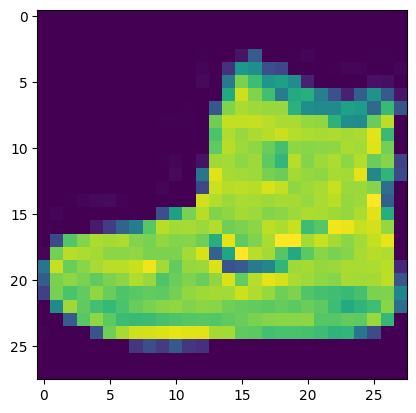

In [5]:
# Plot one of the images
img = train_dataset[0][0].reshape([28, 28])
plt.imshow(img)
plt.show()

In [6]:
# Create model, optimizer, loss function
cnn_model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1), # Shape stays 28x28, get 16 feature fields
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2), # Shape becomes 14x14
    nn.Dropout(p=0.25), # Kill 25% of neurons to prevent codependence.

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2), # Becomes 7x7
    nn.Dropout(p=0.25),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Dropout(p=0.25),
    nn.Flatten(), # 7 x 7 x 128 = 6272

    nn.Linear(6272, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(p=0.25),
    nn.Linear(128, 10)
)

cnn_model = cnn_model.to(device)

opt = optim.Adam(cnn_model.parameters(), lr=0.001)
scheduler = StepLR(opt, step_size=2, gamma=0.7)
loss_ft = nn.CrossEntropyLoss()

In [7]:
# Training and validation

train_losses = []
train_accs = []
val_accs = []

for epoch in range(20):

  # Train
  cnn_model.train()

  total_loss = 0
  total_acc = 0

  for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    pred = cnn_model(X_batch)
    loss = loss_ft(pred, y_batch)
    loss.backward()
    opt.step()
    opt.zero_grad()

    total_loss += loss.item()

    # Calculate accuracy of predictions
    predicted = pred.argmax(dim=1)
    correct = (predicted == y_batch).sum().item()
    total_acc += correct

  avg_train_loss = total_loss / len(train_loader)
  avg_acc = total_acc / len(train_set)
  scheduler.step()


  # Validate
  cnn_model.eval()
  total_val_correct = 0
  with torch.no_grad():
    for X_batch, y_batch in val_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      pred_val = cnn_model(X_batch)
      total_val_correct += (pred_val.argmax(dim=1) == y_batch).sum().item()

  val_acc = total_val_correct / len(val_set)

  train_losses.append(avg_train_loss)
  train_accs.append(avg_acc)

  val_accs.append(val_acc)

  print(f'Epoch {epoch}')
  print(f'Training Set Cross Entropy Loss: {avg_train_loss:.4f}')
  print(f'\nTraining Set Accuracy: {avg_acc:.4f}')
  print(f'Validation Set Accuracy: {val_acc:.4f}\n')

Epoch 0
Training Set Cross Entropy Loss: 0.4456

Training Set Accuracy: 0.8426
Validation Set Accuracy: 0.8970

Epoch 1
Training Set Cross Entropy Loss: 0.3152

Training Set Accuracy: 0.8861
Validation Set Accuracy: 0.9005

Epoch 2
Training Set Cross Entropy Loss: 0.2730

Training Set Accuracy: 0.9007
Validation Set Accuracy: 0.9136

Epoch 3
Training Set Cross Entropy Loss: 0.2541

Training Set Accuracy: 0.9071
Validation Set Accuracy: 0.9144

Epoch 4
Training Set Cross Entropy Loss: 0.2326

Training Set Accuracy: 0.9149
Validation Set Accuracy: 0.9253

Epoch 5
Training Set Cross Entropy Loss: 0.2217

Training Set Accuracy: 0.9176
Validation Set Accuracy: 0.9249

Epoch 6
Training Set Cross Entropy Loss: 0.2064

Training Set Accuracy: 0.9232
Validation Set Accuracy: 0.9238

Epoch 7
Training Set Cross Entropy Loss: 0.1998

Training Set Accuracy: 0.9264
Validation Set Accuracy: 0.9298

Epoch 8
Training Set Cross Entropy Loss: 0.1914

Training Set Accuracy: 0.9288
Validation Set Accuracy: 

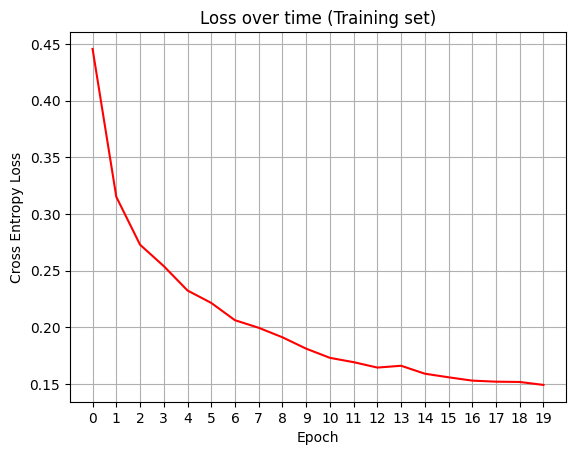

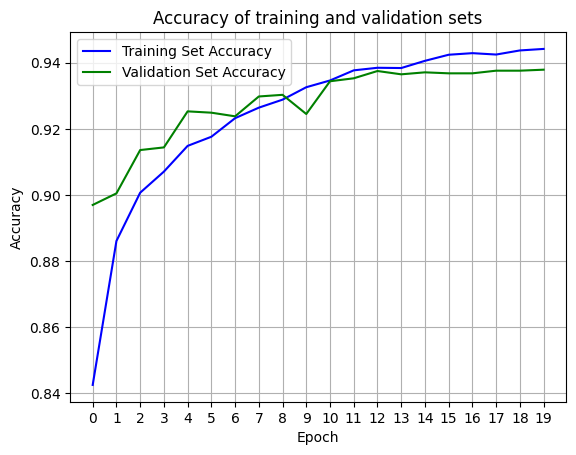

In [8]:
# Print out the results during the training and validation
plt.plot(train_losses, color='red')
plt.grid()
plt.xticks(range(0, 20))
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('Loss over time (Training set)')
plt.show()

plt.plot(train_accs, color='blue', label='Training Set Accuracy')
plt.plot(val_accs, color='green', label='Validation Set Accuracy')
plt.legend()
plt.grid()
plt.xticks(range(0, 20))
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy of training and validation sets')
plt.show()

In [9]:
# Test out the trained model
all_preds = []
all_labels = []

cnn_model.eval()
with torch.no_grad():

  total_test_acc = 0

  for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    pred_test = cnn_model(X_batch)
    total_test_acc += (pred_test.argmax(dim=1) == y_batch).sum().item()

    all_preds.extend(pred_test.argmax(dim=1).cpu().tolist())
    all_labels.extend(y_batch.cpu().tolist())

  test_acc = total_test_acc / len(test_set)

print('Drum roll...')
time.sleep(3)
print(f'Test Set Accuracy: {test_acc:.4f}')

Drum roll...
Test Set Accuracy: 0.9310


In [10]:
# Calculate accuracy per class
class_accuracies = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

class_counts = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for label in all_labels:
    class_counts[label] += 1

for i in range(len(all_preds)):
  if all_preds[i] == all_labels[i]:
    class_accuracies[all_preds[i]] += 1

for j in range(10):
  print(f'Accuracy for {class_names[j]}: {class_accuracies[j] / class_counts[j]:.4f}')

Accuracy for T-shirt: 0.8780
Accuracy for Trouser: 0.9870
Accuracy for Pullover: 0.8850
Accuracy for Dress: 0.9380
Accuracy for Coat: 0.9100
Accuracy for Sandal: 0.9810
Accuracy for Shirt: 0.7970
Accuracy for Sneaker: 0.9820
Accuracy for Bag: 0.9880
Accuracy for Ankle boot: 0.9640


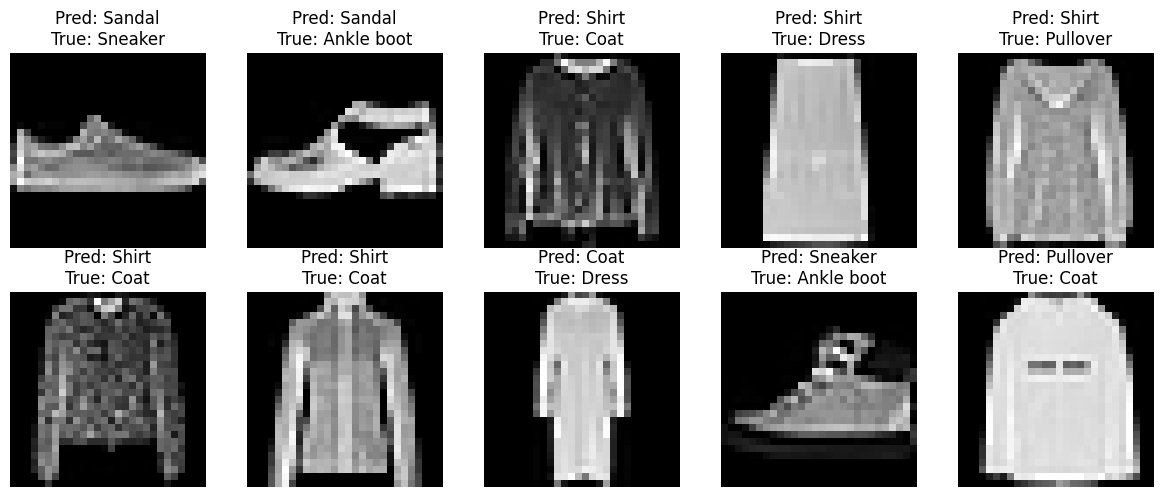

In [11]:
# Plot some wrong predictions
wrong_preds = []

for i in range(len(all_preds)):
  if all_preds[i] != all_labels[i]:
    wrong_preds.append(i)

wrong_ten = wrong_preds[:10]

plt.figure(figsize=(12, 5))
for i in range(10):
    image, label = test_set[wrong_ten[i]]
    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f'Pred: {class_names[all_preds[wrong_ten[i]]]}\nTrue: {class_names[label]}')
    plt.axis('off')
plt.tight_layout()
plt.show()